In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('vnstock_listing_companies.csv')
data.head()

,ticker,exchange,shortName,industry,industryEn,establishedYear,noEmployees,noShareholders,foreignPercent,website,stockRating,outstandingShare,issueShare,companyType,monthlyRecords
0,CMV,HOSE,Thương nghiệp Cà Mau,Bán lẻ,Retail,1980.0,666.0,583.0,0.002,http://www.tncm.com.vn,2.8,18.2,18.2,CT,CMV.csv
1,COM,HOSE,Vật tư Xăng dầu,Bán lẻ,Retail,2000.0,0.0,395.0,0.003,http://comeco.vn,2.6,14.1,14.1,CT,COM.csv
2,DHT,HNX,Dược phẩm Hà Tây,Bán lẻ,Retail,2001.0,795.0,749.0,0.271,http://www.hataphar.com.vn,2.8,26.4,26.4,CT,DHT.csv
3,DGW,HOSE,Thế Giới Số,Bán lẻ,Retail,2003.0,612.0,1228.0,0.259,https://digiworld.com.vn,2.9,163.1,163.2,CT,DGW.csv
4,TTH,HNX,TM và DV Tiến Thành,Bán lẻ,Retail,2003.0,21.0,1452.0,0.003,http://www.tienthanhjsc.vn,NaN,37.4,37.4,CT,TTH.csv


# Câu 1

In [3]:
print('Danh sách các cột dữ liệu')
data.columns.tolist()

Danh sách các cột dữ liệu


['ticker',
 'exchange',
 'shortName',
 'industry',
 'industryEn',
 'establishedYear',
 'noEmployees',
 'noShareholders',
 'foreignPercent',
 'website',
 'stockRating',
 'outstandingShare',
 'issueShare',
 'companyType',
 'monthlyRecords']

In [4]:
print('Dữ liệu bao gồm', data.shape[0], 'dòng và', data.shape[1] , 'cột dữ liệu')

Dữ liệu bao gồm 1155 dòng và 15 cột dữ liệu


# Câu 2

In [5]:
def find_stock(student_id: str):
    order = int(student_id[8:]) % 1000
    ticker = data['ticker'].iloc[order]
    return order, ticker

In [6]:
student_id = '050611231600'
order, ticker = find_stock(student_id)

In [7]:
print('Cổ phiếu số thứ tự', order, ':', ticker)

Cổ phiếu số thứ tự 600 : PAN


# Câu 3

In [8]:
ticker_info_by_index =  data[['ticker', 'shortName', 'monthlyRecords']].iloc[order]

In [9]:
print('ticker:',ticker_info_by_index['ticker'])
print('shortName:',ticker_info_by_index['shortName'])
print('monthlyRecords:',ticker_info_by_index['monthlyRecords'])

ticker: PAN
shortName: Tập đoàn PAN
monthlyRecords: PAN.csv


# Câu 4

In [ ]:
URL = "C:\\Users\\VY\\Desktop\\Thi_CuoiKi\\050611230653\\transaction"
os.chdir(URL)
files = glob.glob(f'*.{'csv'}')

file_name = ticker + '.csv'

if file_name in files:
    ticker_data = pd.read_csv(file_name)
else:
    print(f"Không tìm thấy {file_name}.")

In [11]:
august_september = []
for index, month in enumerate(ticker_data['time']):
    if int(month[5:7]) == 8 or int(month[5:7]) == 9:
        august_september.append(index)

In [12]:
df_augsep = ticker_data[min(august_september) : max(august_september) + 1]
df_augsep = df_augsep.reset_index()
df_augsep = df_augsep.drop(columns = ['index'])

In [13]:
print('Số lượng giao dịch từ tháng 8 tới tháng 9:',len(df_augsep),
    '\nGiá Close cao nhất từ tháng 8 tới tháng 9:' ,df_augsep.describe()['close']['max'],
    '\nGiá Close trung bình từ tháng 8 tới tháng 9:' ,df_augsep.describe()['close']['mean'],
    '\nGiá Close thấp nhất từ tháng 8 tới tháng 9:' ,df_augsep.describe()['close']['min'])

Số lượng giao dịch từ tháng 8 tới tháng 9: 42 
Giá Close cao nhất từ tháng 8 tới tháng 9: 23600.0 
Giá Close trung bình từ tháng 8 tới tháng 9: 22075.0 
Giá Close thấp nhất từ tháng 8 tới tháng 9: 20100.0


# Câu 5

In [14]:
info_1 = []
for close, open in zip(df_augsep['close'], df_augsep['open']):
    if close > open:
        info_1.append(1)
    elif close < open:
        info_1.append(-1)
    else:
        info_1.append(0)

In [15]:
df_augsep['Info01'] = info_1

In [16]:
df_augsep.head()

,time,open,high,low,close,volume,ticker,Info01
0,2023-08-01,23300,23350,22600,22850,2952300,PAN,-1
1,2023-08-02,22700,23400,22650,23400,3011400,PAN,1
2,2023-08-03,23500,23500,22950,23200,2725500,PAN,-1
3,2023-08-04,23300,23400,23200,23250,1449600,PAN,-1
4,2023-08-07,23700,23900,23350,23500,2058500,PAN,-1


# Câu 6

In [17]:
close_previous = ticker_data['close'][min(august_september) - 1 : max(august_september)]
close_follow = ticker_data['close'][min(august_september) : max(august_september) + 1]

In [18]:
info2 = []
for previous, follow in zip(close_previous, close_follow):
    if previous > follow:
        info2.append(-1)
    elif previous < follow:
        info2.append(1)
    else:
        info2.append(0)

In [19]:
df_augsep['Info02'] = info2

In [20]:
df_augsep.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-08-01,23300,23350,22600,22850,2952300,PAN,-1,-1
1,2023-08-02,22700,23400,22650,23400,3011400,PAN,1,1
2,2023-08-03,23500,23500,22950,23200,2725500,PAN,-1,-1
3,2023-08-04,23300,23400,23200,23250,1449600,PAN,-1,1
4,2023-08-07,23700,23900,23350,23500,2058500,PAN,-1,1


In [ ]:
URL = "C:\\Users\\VY\\Desktop\\Thi_CuoiKi\\050611230653"
os.chdir(URL)
df_augsep.to_csv('PAN_stock.csv', index =  False)

# Câu 7

In [22]:
PAN_data = pd.read_csv('PAN_stock.csv')
PAN_data.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-08-01,23300,23350,22600,22850,2952300,PAN,-1,-1
1,2023-08-02,22700,23400,22650,23400,3011400,PAN,1,1
2,2023-08-03,23500,23500,22950,23200,2725500,PAN,-1,-1
3,2023-08-04,23300,23400,23200,23250,1449600,PAN,-1,1
4,2023-08-07,23700,23900,23350,23500,2058500,PAN,-1,1


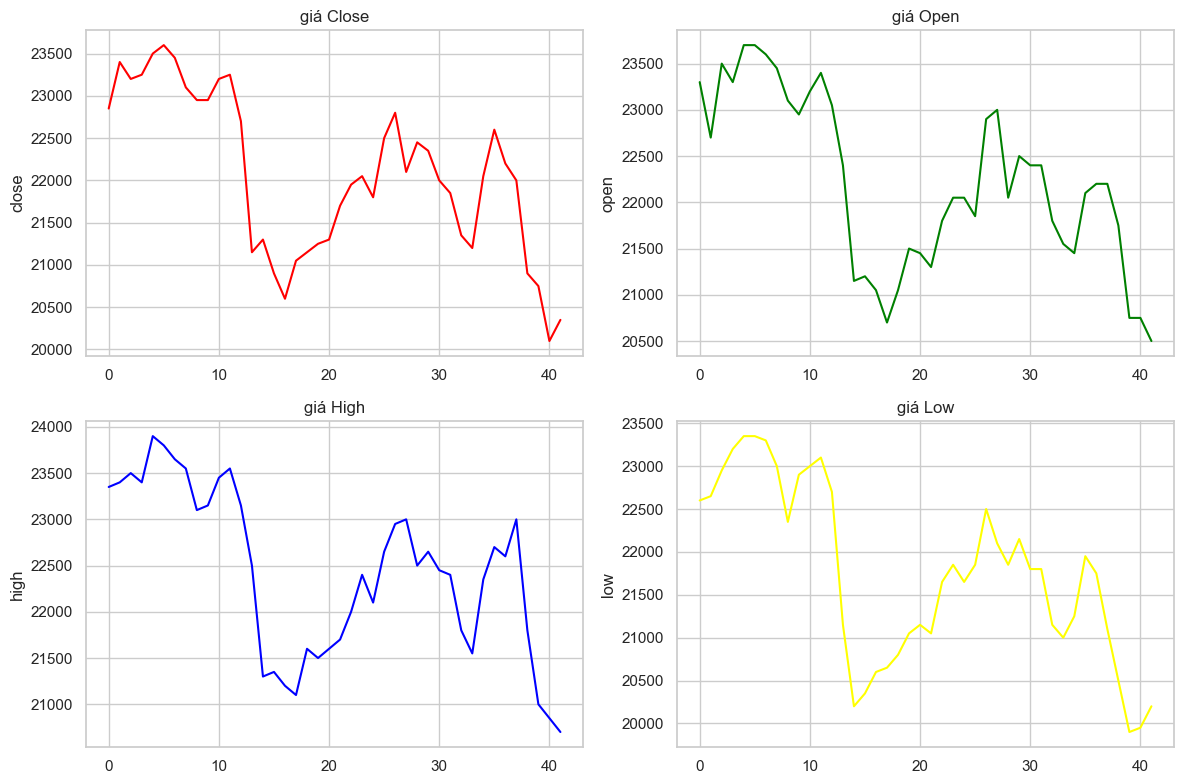

In [23]:
sns.set_theme(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.lineplot(data = PAN_data['close'], ax=axes[0, 0], color='red')
axes[0, 0].set_title('giá Close')

sns.lineplot(data = PAN_data['open'], ax=axes[0, 1], color='green')
axes[0, 1].set_title('giá Open')

sns.lineplot(data = PAN_data['high'], ax=axes[1, 0], color='blue')
axes[1, 0].set_title('giá High')

sns.lineplot(data = PAN_data['low'], ax=axes[1, 1], color='yellow')
axes[1, 1].set_title('giá Low')

plt.tight_layout()
plt.show()


# Câu 8

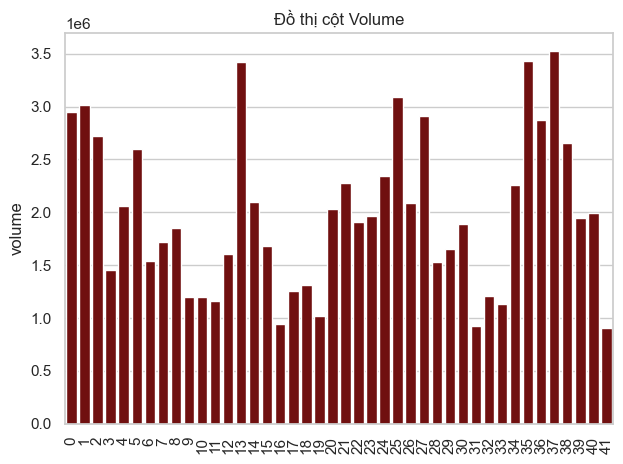

In [24]:
sns.barplot(data = PAN_data['volume'], color = 'maroon')
plt.xticks(rotation = 90)
plt.title('Đồ thị cột Volume')
plt.tight_layout()
plt.show()

# Câu 9

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
X = PAN_data['volume']
X = X.values.reshape(-1, 1) if isinstance(X, pd.Series) else X

y = PAN_data['close']
y = y.values if isinstance(y, pd.Series) else y

In [27]:
linear_model = LinearRegression()

In [28]:
linear_model.fit(X, y)

LinearRegression()

# Câu 10

In [29]:
rand_vol = np.random.randint(PAN_data.describe()['volume']['min'], PAN_data.describe()['volume']['max'], size = 10)

In [30]:
y_predict = linear_model.predict(rand_vol.reshape(-1, 1))

In [31]:
print('Dự báo giá Close mới dựa trên Volume:')
new_data = pd.DataFrame({'random volume': rand_vol,'predicted close': y_predict})
new_data

Dự báo giá Close mới dựa trên Volume:


,random volume,predicted close
0,2257704,22143.154268
1,3112373,22356.052645
2,2231088,22136.524213
3,1313528,21907.959664
4,1336134,21913.590827
5,1530456,21961.996512
6,1677231,21998.558221
7,1327218,21911.369848
8,1079611,21849.690849
9,1398591,21929.148890
